In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 读取数据（假设已加载为DataFrame）
df = pd.read_excel("processed_dataset.xlsx", sheet_name="Sheet1")

In [2]:
# 编码类别标签（pollutant）
le = LabelEncoder()
df['pollutant'] = le.fit_transform(df['pollutant'])

# 分离特征和目标
X = df.drop(columns=['pollutant', 'kobs'])  # 输入特征
y_category = df['pollutant']              # 类别标签（用于分层）
y_reg = df['kobs']                         # 回归目标
feature_name = X.columns.tolist()
X = X.values
y_reg = y_reg.values

# 标准化特征（AutoTabPFN对尺度敏感）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [3]:
# 分层划分：保持类别分布一致
X_train, X_test, y_train, y_test, y_cat_train, y_cat_test = train_test_split(
    X, y_reg, y_category,
    test_size=0.2,
    stratify=y_category,  # 按pollutant分层
    random_state=42
)

In [4]:
from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import AutoTabPFNRegressor

# 初始化模型
model = AutoTabPFNRegressor(max_time=120, device='cuda')

# 训练（AutoTabPFN适合小数据，大数据需调整）
model.fit(X_train, y_train)

# 预测
y_test_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

E:\miniconda\envs\tabpfn\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


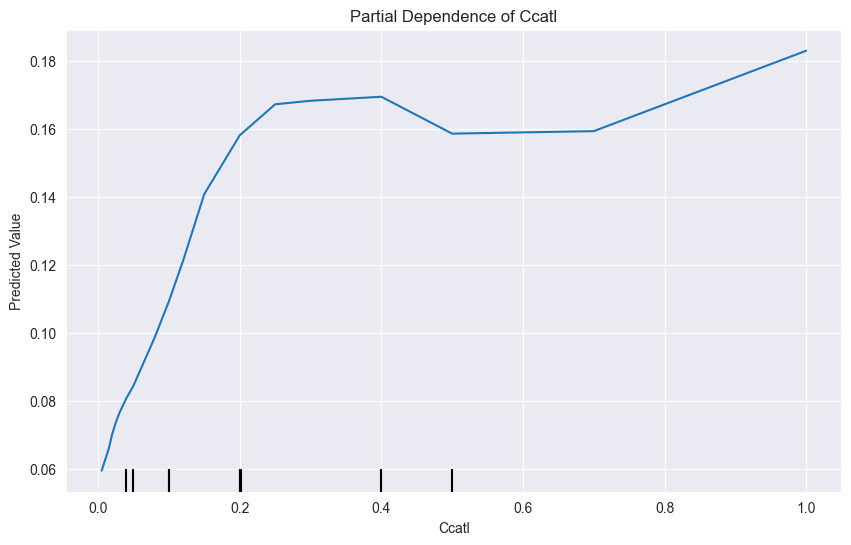

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# 选择目标特征（例如第一个特征）
target_feature_index = 14  # 替换为需要分析的特征索引

# 创建PDP图
fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    features=[target_feature_index],  # 分析单个特征
    feature_names=feature_name,
    ax=ax
)
plt.title(f"Partial Dependence of {feature_name[target_feature_index]}")
plt.ylabel("Predicted Value")
plt.show()

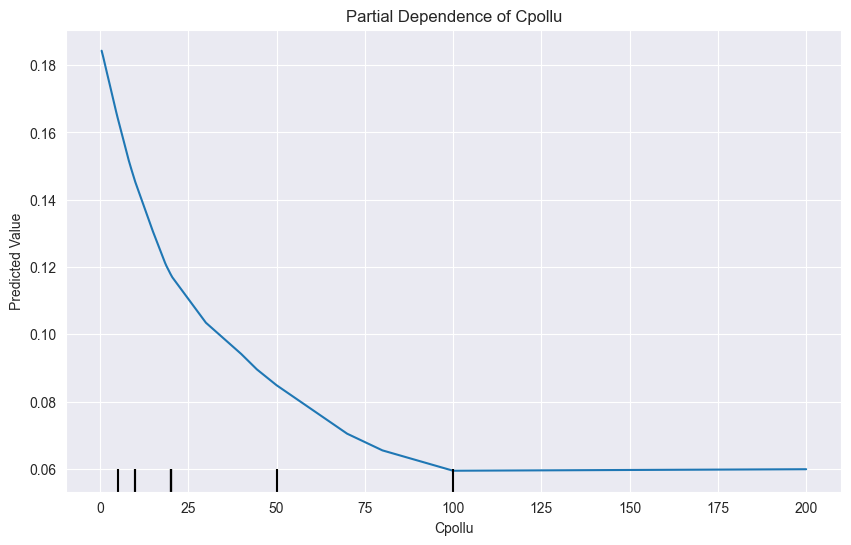

In [6]:
# 选择目标特征（例如第一个特征）
target_feature_index = 19  # 替换为需要分析的特征索引

# 创建PDP图
fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    features=[target_feature_index],  # 分析单个特征
    feature_names=feature_name,
    ax=ax
)
plt.title(f"Partial Dependence of {feature_name[target_feature_index]}")
plt.ylabel("Predicted Value")
plt.show()

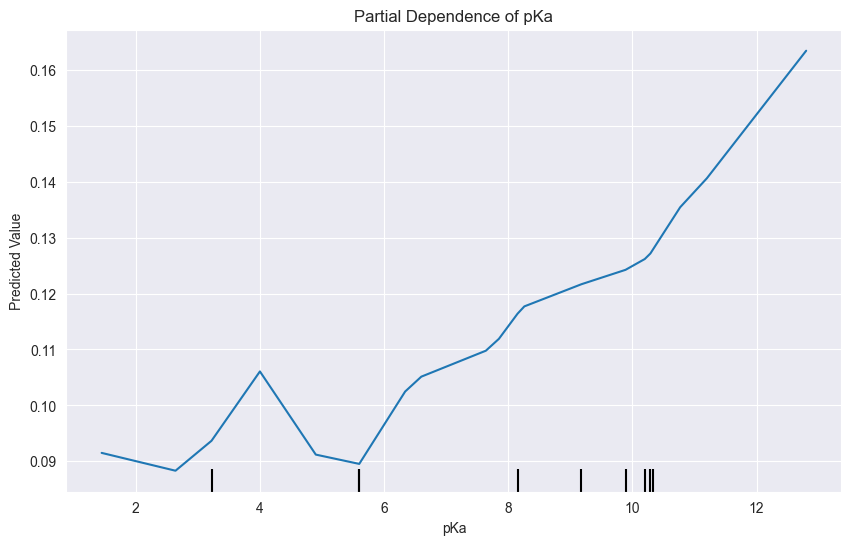

In [7]:
# 选择目标特征（例如第一个特征）
target_feature_index = 21  # 替换为需要分析的特征索引

# 创建PDP图
fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    features=[target_feature_index],  # 分析单个特征
    feature_names=feature_name,
    ax=ax
)
plt.title(f"Partial Dependence of {feature_name[target_feature_index]}")
plt.ylabel("Predicted Value")
plt.show()

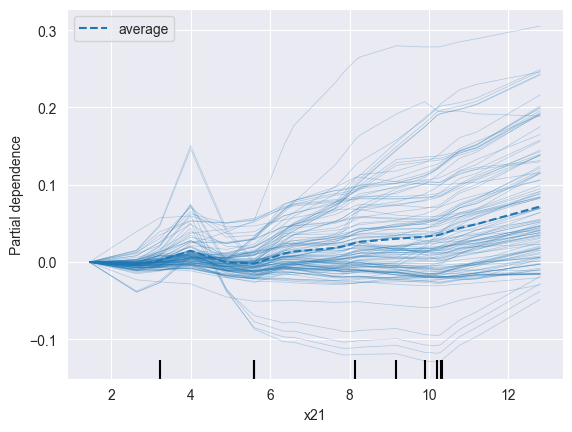

In [8]:
PartialDependenceDisplay.from_estimator(
    model, X_test, features=[21],
    kind='both',  # 同时显示PDP和ICE
    centered=True
)

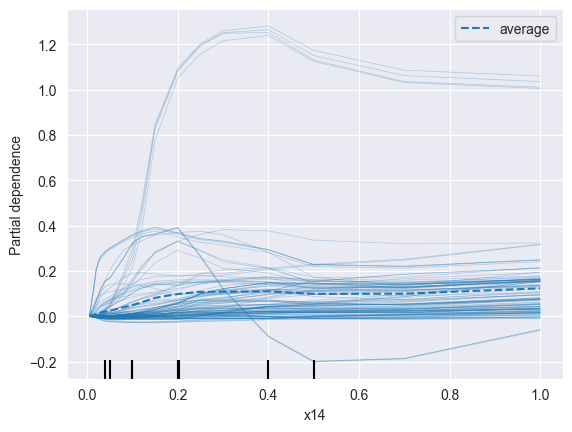

In [10]:
PartialDependenceDisplay.from_estimator(
    model, X_test, features=[14],
    kind='both',  # 同时显示PDP和ICE
    centered=True
)

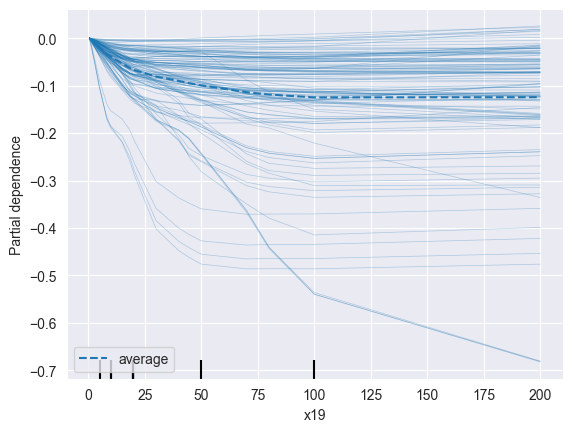

In [11]:
PartialDependenceDisplay.from_estimator(
    model, X_test, features=[19],
    kind='both',  # 同时显示PDP和ICE
    centered=True
)